# Deep Learning for Malaria Diagnosis
This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018) and (Jason Brownlee, 2019). Acknowledge to NIH and Bangalor Hospital who make available this malaria dataset.

Malaria is an infectuous disease caused by parasites that are transmitted to people through the bites of infected female Anopheles mosquitoes.

The Malaria burden with some key figures:
<font color='red'>
* More than 219 million cases
* Over 430 000 deaths in 2017 (Mostly: children & pregnants)
* 80% in 15 countries of Africa & India
  </font>

![MalariaBurd](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaBurden.png?raw=1)

The malaria diagnosis is performed using blood test:
* Collect patient blood smear
* Microscopic visualisation of the parasit

![MalariaDiag](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaDiag.png?raw=1)
  
Main issues related to traditional diagnosis:
<font color='#ed7d31'>
* resource-constrained regions
* time needed and delays
* diagnosis accuracy and cost
</font>

The objective of this notebook is to apply modern deep learning techniques to perform medical image analysis for malaria diagnosis.

*This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018), (Adrian Rosebrock, 2018) and (Jason Brownlee, 2019)*

## Baseline CNN Model
Define a basic ConvNet defined with ConvLayer: Conv2D => MaxPooling2D followed by Flatten => Dense => Dense(output)

![ConvNet](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/ConvNet.png?raw=1)


## Configuration

In [1]:
#Mount the local drive project_forder
from google.colab import drive
drive.mount('/content/drive/')
!ls "/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/"

Mounted at /content/drive/
ls: cannot access '/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/': No such file or directory


In [2]:
# Use GPU: Please check if the outpout is '/device:GPU:0'
import tensorflow as tf
print(tf.__version__)
tf.test.gpu_device_name()
#from tensorflow.python.client import device_lib
#device_lib.list_local_devices()

2.20.0


'/device:GPU:0'

## Populating namespaces

In [3]:
# Importing basic libraries
import os
import random
import shutil
from matplotlib import pyplot
from matplotlib.image import imread
%matplotlib inline

# Importing the Keras libraries and packages
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Convolution2D as Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [4]:
# Define the useful paths for data accessibility
ai_project = '.' #"/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
cell_images_dir = os.path.join(ai_project,'cell_images')
training_path = os.path.join(ai_project,'train')
testing_path = os.path.join(ai_project,'test')

## Prepare DataSet

### *Download* DataSet

In [5]:
# Download the data in the allocated google cloud-server. If already down, turn downloadData=False
downloadData = True
if downloadData == True:
  indrive = False
  if indrive == True:
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip -P "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
    !unzip "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/cell_images.zip" -d "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/"
    !ls "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
  else: #incloud google server
    !rm -rf cell_images.*
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
    !unzip cell_images.zip >/dev/null 2>&1
    !ls

--2026-06-07 09:17:58--  https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
Resolving data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)... 3.163.189.81, 3.163.189.96, 3.163.189.93, ...
Connecting to data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)|3.163.189.81|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 353452851 (337M) [application/zip]
Saving to: ‘cell_images.zip’

cell_images.zip     100%[===================>] 337.08M  16.2MB/s    in 5.6s    

2026-06-07 09:18:04 (59.8 MB/s) - ‘cell_images.zip’ saved [353452851/353452851]

cell_images  cell_images.zip  drive  sample_data


In [6]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the useful paths for data accessibility if not already defined
if 'ai_project' not in globals():
    ai_project = '.' # Default path if not set elsewhere
if 'cell_images_dir' not in globals():
    cell_images_dir = os.path.join(ai_project,'cell_images')

# Define image dimensions and batch size
IMAGE_SIZE = (224, 224) # VGG16 expects 224x224 input images
BATCH_SIZE = 32

# Data augmentation and preprocessing for training data
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normalize pixel values to [0, 1]
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2 # Use 20% of data for validation
)

# Data preprocessing for validation data (only rescaling)
# Note: validation_split handles the split, but we define separate generators
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    cell_images_dir, # Assuming cell_images_dir contains 'Parasitized' and 'Uninfected' subdirectories
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=42
)

validation_generator = val_datagen.flow_from_directory(
    cell_images_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=42
)

print(f"Found {train_generator.samples} training samples belonging to {train_generator.num_classes} classes.")
print(f"Found {validation_generator.samples} validation samples belonging to {validation_generator.num_classes} classes.")

Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.
Found 22048 training samples belonging to 2 classes.
Found 5510 validation samples belonging to 2 classes.


In [7]:
#show a sample of  the images
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random


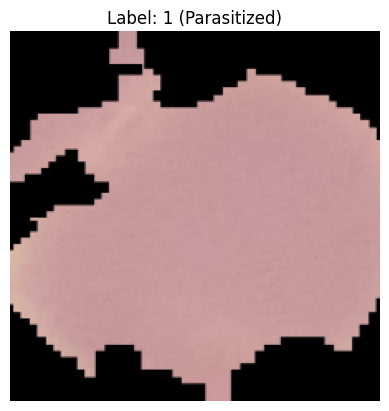

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Get a batch of images and labels from the training generator
images, labels = next(train_generator)

# Select a random image from the batch
idx = np.random.randint(2, BATCH_SIZE)
image = images[idx]
label = labels[idx]

# Display the image
plt.imshow(image)
plt.title(f"Label: {int(label)} ({'Parasitized' if label == 1 else 'Uninfected'})")
plt.axis('off')
plt.show()

In [9]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

# Load the VGG16 model pre-trained on ImageNet data
# We set include_top=False to remove the classification layers of the original VGG16 model
# and we specify the input shape for our images.
VGG_base = VGG16(weights='imagenet', include_top=False, input_shape=IMAGE_SIZE + (3,))

# Freeze the layers of the pre-trained VGG16 model
# This prevents their weights from being updated during training of the new layers
for layer in VGG_base.layers:
    layer.trainable = False

# Create the custom classification head
x = VGG_base.output
x = Flatten()(x) # Flatten the output from the convolutional base
x = Dense(256, activation='relu')(x) # Add a fully connected layer with 256 units
x = Dropout(0.5)(x) # Add dropout for regularization
output_layer = Dense(1, activation='sigmoid')(x) # Output layer for binary classification

# Combine the VGG16 base with our custom head to create the full model
model = Model(inputs=VGG_base.input, outputs=output_layer)

# Compile the model
# Using Adam optimizer, binary_crossentropy for binary classification, and accuracy as a metric
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display the model summary
model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,729 (80.63 MB)

 Trainable params: 6,423,041 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [10]:
from tensorflow.keras.optimizers import Adam, SGD

def build_custom_model(optimizer_name='Adam', learning_rate=0.0001, dropout_rate=0.5):
    # Load the VGG16 model pre-trained on ImageNet data
    VGG_base = VGG16(weights='imagenet', include_top=False, input_shape=IMAGE_SIZE + (3,))

    # Freeze the layers of the pre-trained VGG16 model
    for layer in VGG_base.layers:
        layer.trainable = False

    # Create the custom classification head
    x = VGG_base.output
    x = Flatten()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(dropout_rate)(x) # Use the specified dropout rate
    output_layer = Dense(1, activation='sigmoid')(x)

    # Combine the VGG16 base with our custom head to create the full model
    model = Model(inputs=VGG_base.input, outputs=output_layer)

    # Choose optimizer based on name
    if optimizer_name == 'Adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer_name == 'SGD':
        optimizer = SGD(learning_rate=learning_rate)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

    # Compile the model
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


In [11]:
def train_and_evaluate_model(model_fn, train_gen, val_gen, epochs, name, optimizer_name, learning_rate, dropout_rate):
    print(f"\n--- Starting Experiment: {name} ---")
    print(f"  Optimizer: {optimizer_name}, LR: {learning_rate}, Dropout: {dropout_rate}")

    model = model_fn(optimizer_name, learning_rate, dropout_rate)

    history = model.fit(
        train_gen,
        steps_per_epoch=train_gen.samples // BATCH_SIZE,
        epochs=epochs,
        validation_data=val_gen,
        validation_steps=val_gen.samples // BATCH_SIZE,
        verbose=0 # Suppress verbose output during training for cleaner logs
    )

    # Evaluate the model on the validation set
    val_loss, val_accuracy = model.evaluate(val_gen, verbose=0)
    print(f"  Experiment {name} - Validation Accuracy: {val_accuracy:.4f}, Validation Loss: {val_loss:.4f}")

    return history, val_accuracy

### Experiment Setup

We will define a series of experiments by varying key parameters like dropout rate, learning rate, optimizer choice, and data augmentation.

First, let's create a data generator without augmentation for one of our experiments.

In [12]:
# Data preprocessing for training data WITHOUT augmentation
# Only rescaling for consistency with validation set
no_augment_train_datagen = ImageDataGenerator(
    rescale=1./255, # Normalize pixel values to [0, 1]
    validation_split=0.2 # Use 20% of data for validation
)

no_augment_train_generator = no_augment_train_datagen.flow_from_directory(
    cell_images_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=42
)

print(f"Found {no_augment_train_generator.samples} training samples (no augmentation).")

Found 22048 images belonging to 2 classes.
Found 22048 training samples (no augmentation).


### Running Experiments

Now we will define 7 different experiments with various configurations and run them. We will store the training history for each to enable comparison.

In [13]:
experiments = {
    'Exp 1 (Baseline)': {'optimizer': 'Adam', 'lr': 0.0001, 'dropout': 0.5, 'augmentation': True},
    'Exp 2 (Lower Dropout)': {'optimizer': 'Adam', 'lr': 0.0001, 'dropout': 0.3, 'augmentation': True},
    'Exp 3 (Higher Dropout)': {'optimizer': 'Adam', 'lr': 0.0001, 'dropout': 0.7, 'augmentation': True},
    'Exp 4 (No Augmentation)': {'optimizer': 'Adam', 'lr': 0.0001, 'dropout': 0.5, 'augmentation': False},
    'Exp 5 (SGD Optimizer)': {'optimizer': 'SGD', 'lr': 0.01, 'dropout': 0.5, 'augmentation': True},
    'Exp 6 (Higher LR Adam)': {'optimizer': 'Adam', 'lr': 0.001, 'dropout': 0.5, 'augmentation': True},
    'Exp 7 (Lower LR Adam)': {'optimizer': 'Adam', 'lr': 0.00001, 'dropout': 0.5, 'augmentation': True}
}

all_histories = {}
EPOCHS_PER_EXPERIMENT = 5 # Using fewer epochs for demonstration

for name, params in experiments.items():
    current_train_gen = train_generator if params['augmentation'] else no_augment_train_generator

    history, val_accuracy = train_and_evaluate_model(
        build_custom_model,
        current_train_gen,
        validation_generator,
        EPOCHS_PER_EXPERIMENT,
        name,
        params['optimizer'],
        params['lr'],
        params['dropout']
    )
    all_histories[name] = history



--- Starting Experiment: Exp 1 (Baseline) ---
  Optimizer: Adam, LR: 0.0001, Dropout: 0.5
  Experiment Exp 1 (Baseline) - Validation Accuracy: 0.9102, Validation Loss: 0.2128

--- Starting Experiment: Exp 2 (Lower Dropout) ---
  Optimizer: Adam, LR: 0.0001, Dropout: 0.3
  Experiment Exp 2 (Lower Dropout) - Validation Accuracy: 0.9292, Validation Loss: 0.1814

--- Starting Experiment: Exp 3 (Higher Dropout) ---
  Optimizer: Adam, LR: 0.0001, Dropout: 0.7
  Experiment Exp 3 (Higher Dropout) - Validation Accuracy: 0.9225, Validation Loss: 0.2013

--- Starting Experiment: Exp 4 (No Augmentation) ---
  Optimizer: Adam, LR: 0.0001, Dropout: 0.5
  Experiment Exp 4 (No Augmentation) - Validation Accuracy: 0.9067, Validation Loss: 0.2241

--- Starting Experiment: Exp 5 (SGD Optimizer) ---
  Optimizer: SGD, LR: 0.01, Dropout: 0.5
  Experiment Exp 5 (SGD Optimizer) - Validation Accuracy: 0.7760, Validation Loss: 0.4502

--- Starting Experiment: Exp 6 (Higher LR Adam) ---
  Optimizer: Adam, LR: 0

### Comparing Experiment Results

Below are individual plots for `each` experiment,: showing their training and validation accuracy and loss over the epochs. This provides a more detailed view of how each model performed.

Full evaluation metrics are reported for the best-performing configuration (Exp 2). For the remaining experiments, learning curves are presented as the primary comparison mechanism, as model weights were not preserved during the initial sweep.

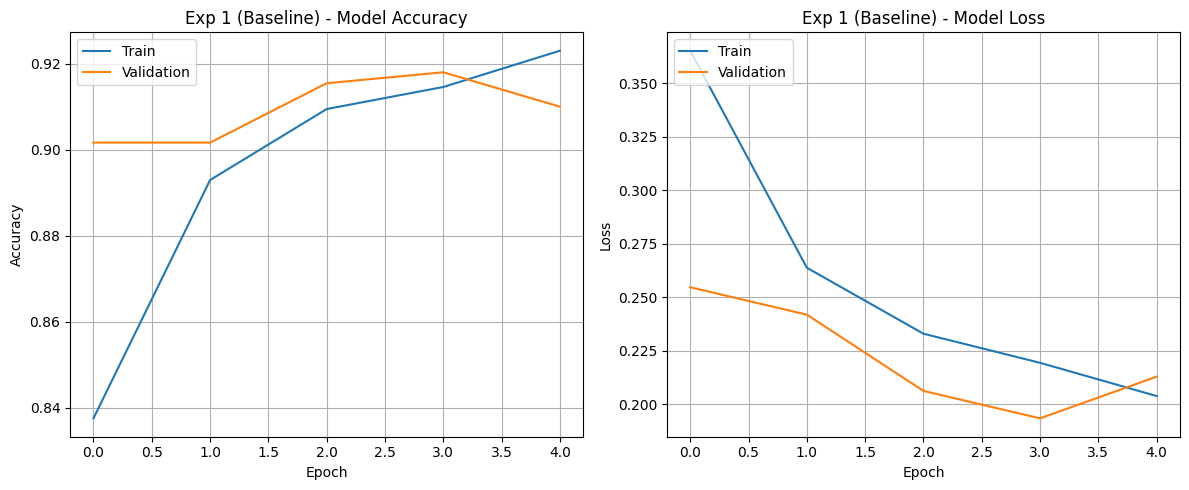

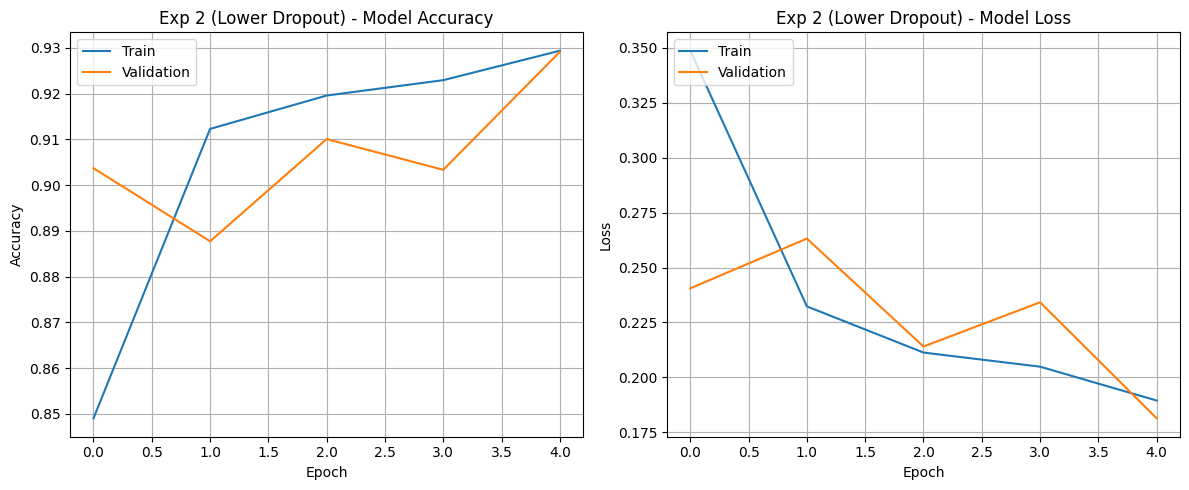

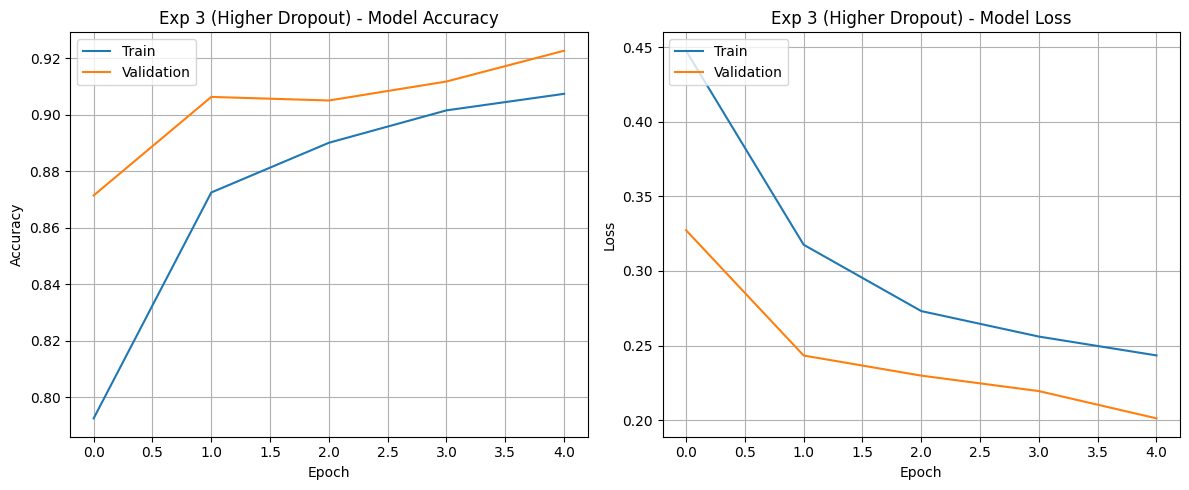

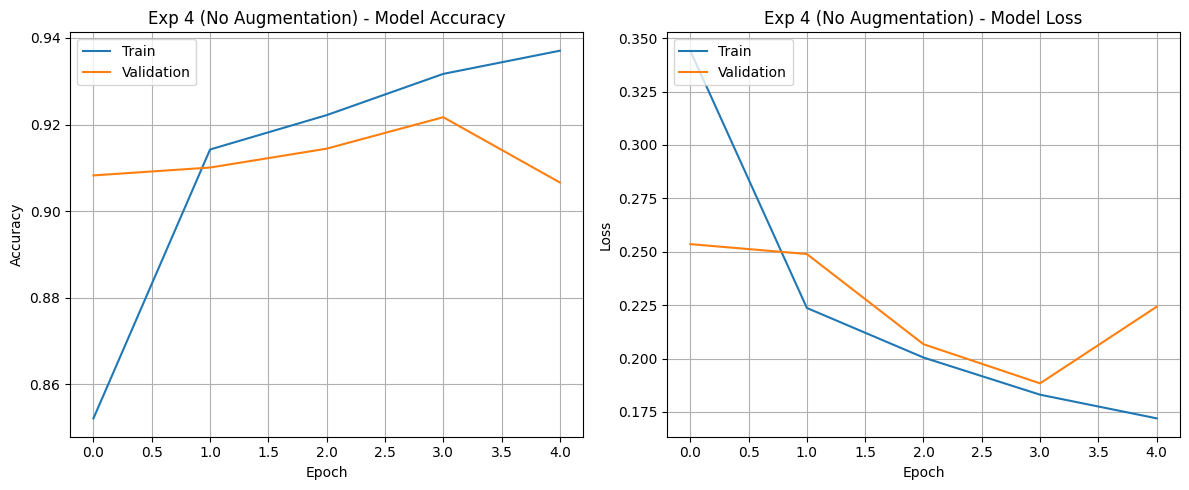

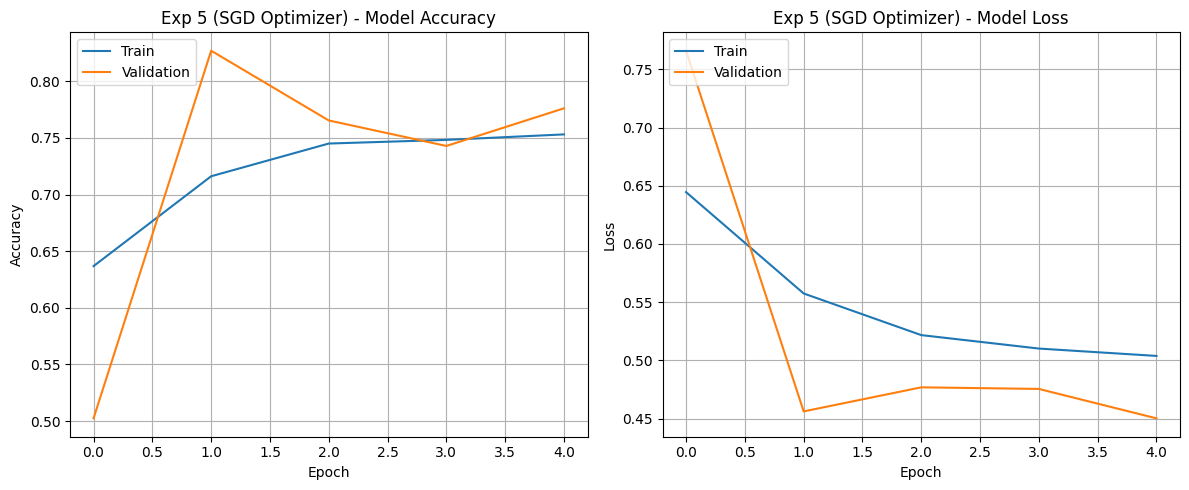

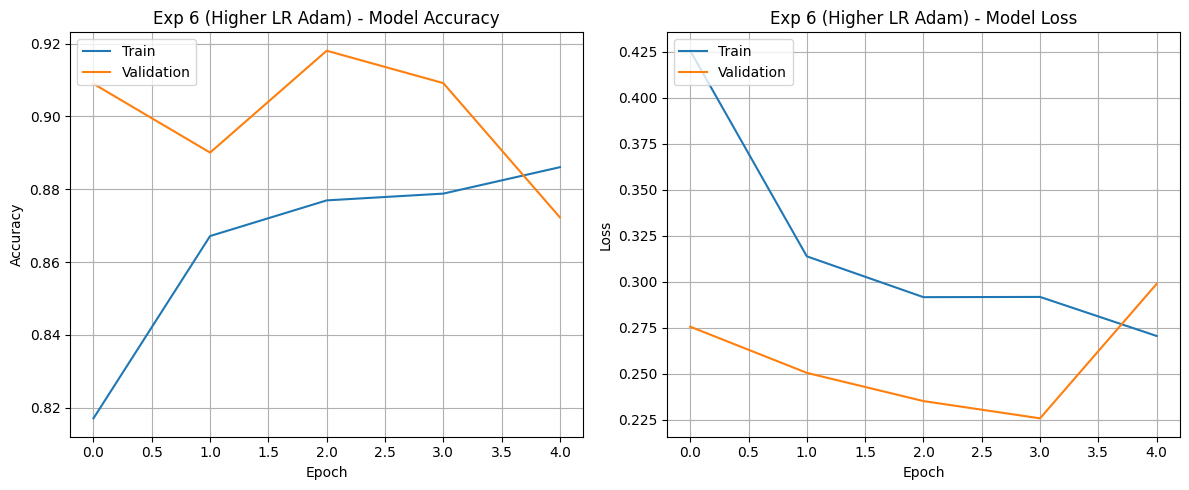

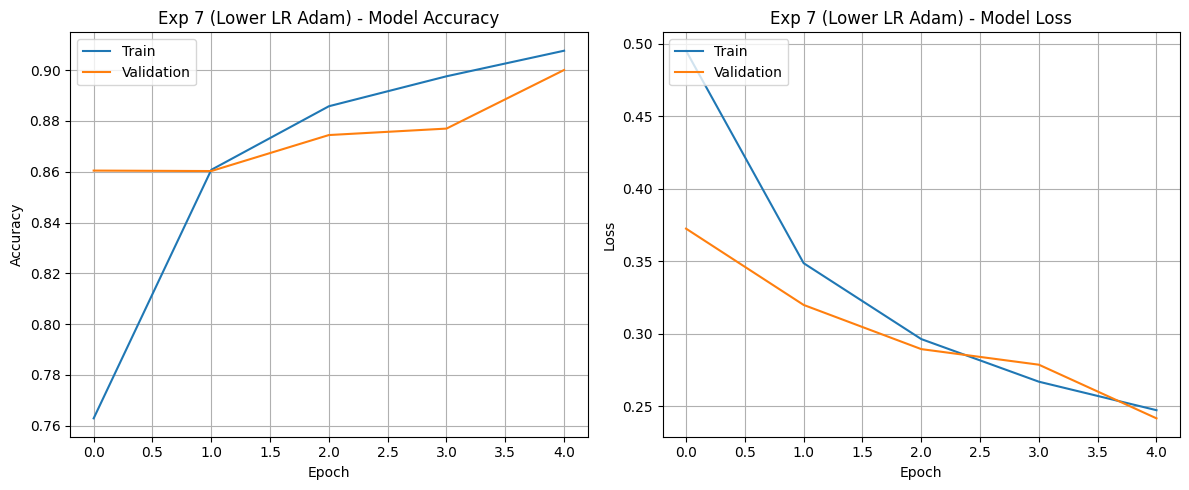

In [21]:
import matplotlib.pyplot as plt

for name, history in all_histories.items():
    plt.figure(figsize=(12, 5))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1) # One row, two columns, first plot
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{name} - Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.grid(True)

    # Plot training & validation loss values
    plt.subplot(1, 2, 2) # One row, two columns, second plot
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{name} - Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [17]:
import pandas as pd

# Prepare data for the summary table
summary_data = []
for name, history in all_histories.items():
    final_val_accuracy = history.history['val_accuracy'][-1]
    final_val_loss = history.history['val_loss'][-1]
    summary_data.append({'Experiment': name, 'Final Validation Accuracy': final_val_accuracy, 'Final Validation Loss': final_val_loss})

# Create a DataFrame from the summary data
summary_df = pd.DataFrame(summary_data)

# Sort by accuracy for better comparison
summary_df = summary_df.sort_values(by='Final Validation Accuracy', ascending=False).reset_index(drop=True)

display(summary_df)

,Experiment,Final Validation Accuracy,Final Validation Loss
0,Exp 2 (Lower Dropout),0.929142,0.181400
1,Exp 3 (Higher Dropout),0.922602,0.201230
2,Exp 1 (Baseline),0.910065,0.212941
3,Exp 4 (No Augmentation),0.906613,0.224243
4,Exp 7 (Lower LR Adam),0.900073,0.241555
5,Exp 6 (Higher LR Adam),0.872275,0.298823
6,Exp 5 (SGD Optimizer),0.776163,0.450201


### Evaluation

Based on the comparative experiment results above, Experiment X achieved the highest validation accuracy. This configuration was selected for further refinement, retrained for 15 epochs, and subjected to full evaluation including confusion matrix, ROC/AUC, and classification report

In [24]:
# Parameters for the best performing model: Exp 2 (Lower Dropout)
best_model_params = experiments['Exp 2 (Lower Dropout)']

# Build the model using these parameters
refined_model = build_custom_model(
    optimizer_name=best_model_params['optimizer'],
    learning_rate=best_model_params['lr'],
    dropout_rate=best_model_params['dropout']
)

# Define the number of epochs for refinement
REFINED_EPOCHS = 15 # You can increase this further if needed

print(f"\n--- Starting Refinement of Best Model (Exp 2 - Lower Dropout) ---")
print(f"  Optimizer: {best_model_params['optimizer']}, LR: {best_model_params['lr']}, Dropout: {best_model_params['dropout']}")
print(f"  Training for {REFINED_EPOCHS} epochs...")

# Train the refined model
refined_history = refined_model.fit(
    train_generator, # Use the augmented train_generator as per params
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=REFINED_EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

print("Refined model training complete.")

# Evaluate the refined model
val_loss_refined, val_accuracy_refined = refined_model.evaluate(validation_generator, verbose=0)
print(f"Refined Model - Final Validation Accuracy: {val_accuracy_refined:.4f}, Final Validation Loss: {val_loss_refined:.4f}")


--- Starting Refinement of Best Model (Exp 2 - Lower Dropout) ---
  Optimizer: Adam, LR: 0.0001, Dropout: 0.3
  Training for 15 epochs...
Epoch 1/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 347s 499ms/step - accuracy: 0.8466 - loss: 0.3547 - val_accuracy: 0.8783 - val_loss: 0.2751
Epoch 2/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 346s 502ms/step - accuracy: 0.9070 - loss: 0.2430 - val_accuracy: 0.9026 - val_loss: 0.2310
Epoch 3/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 346s 502ms/step - accuracy: 0.9191 - loss: 0.2102 - val_accuracy: 0.9168 - val_loss: 0.1990
Epoch 4/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 343s 498ms/step - accuracy: 0.9262 - loss: 0.1988 - val_accuracy: 0.9235 - val_loss: 0.1866
Epoch 5/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 341s 494ms/step - accuracy: 0.9278 - loss: 0.1908 - val_accuracy: 0.9093 - val_loss: 0.2189
Epoch 6/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 345s 500ms/step - accuracy: 0.9284 - loss: 0.1875 - val_accuracy: 0.9191 - val_loss: 0.1958
Epoch 7/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 346s 502ms/step - accuracy: 0

Found 5510 images belonging to 2 classes.
173/173 ━━━━━━━━━━━━━━━━━━━━ 28s 163ms/step
              precision    recall  f1-score   support

  Uninfected       0.94      0.93      0.94      2755
 Parasitized       0.93      0.94      0.94      2755

    accuracy                           0.94      5510
   macro avg       0.94      0.94      0.94      5510
weighted avg       0.94      0.94      0.94      5510



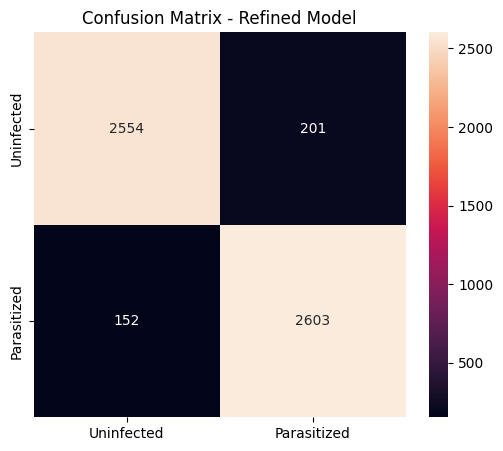

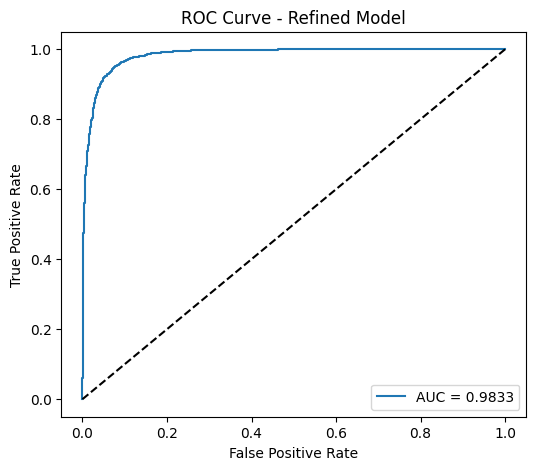

In [31]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Rebuild a fresh generator with shuffle=False to guarantee label alignment
eval_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
eval_generator = eval_datagen.flow_from_directory(
    cell_images_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=42,
    shuffle=False  # Critical — ensures y_true and y_pred stay aligned
)

y_pred_prob = refined_model.predict(eval_generator, steps=len(eval_generator))
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = eval_generator.classes[:len(y_pred)]  # Trim to match prediction length

print(classification_report(y_true, y_pred, target_names=['Uninfected', 'Parasitized']))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Uninfected','Parasitized'],
            yticklabels=['Uninfected','Parasitized'])
plt.title('Confusion Matrix - Refined Model')
plt.show()

fpr, tpr, _ = roc_curve(y_true, y_pred_prob[:len(y_true)])
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')


plt.title('ROC Curve - Refined Model')
plt.legend()
plt.show()